In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("Air Traffic Data Updated.csv",parse_dates=['Date'],index_col='Date')
df.head()

,domestic passengers,international passenegrs,domestic freight(in tonne),international freight(in tonne),GDP (in dollars),Population,Jet Fuel Price per Gallon,Inflation Rate,Unemployement Rate,Rupees Exchange Rate
Date,,,,,,,,,,
2009-01-01,3288004,885435,20832,11675,1.341888e+12,1225524753,71.75,10.88,7.66,48.70
2009-01-02,3293220,757168,18645,12482,1.341888e+12,1225524753,61.97,10.88,7.66,49.25
2009-01-03,3122400,848046,23046,15359,1.341888e+12,1225524753,65.01,10.88,7.66,51.13
2009-01-04,3266686,861715,21623,14512,1.341888e+12,1225524753,68.55,10.88,7.66,49.97
2009-01-05,3883887,898410,19534,14586,1.341888e+12,1225524753,72.22,10.88,7.66,48.51


In [4]:
df_corr = df.drop(columns=['Date'], errors='ignore')

In [5]:
corr_matrix = df_corr.corr()

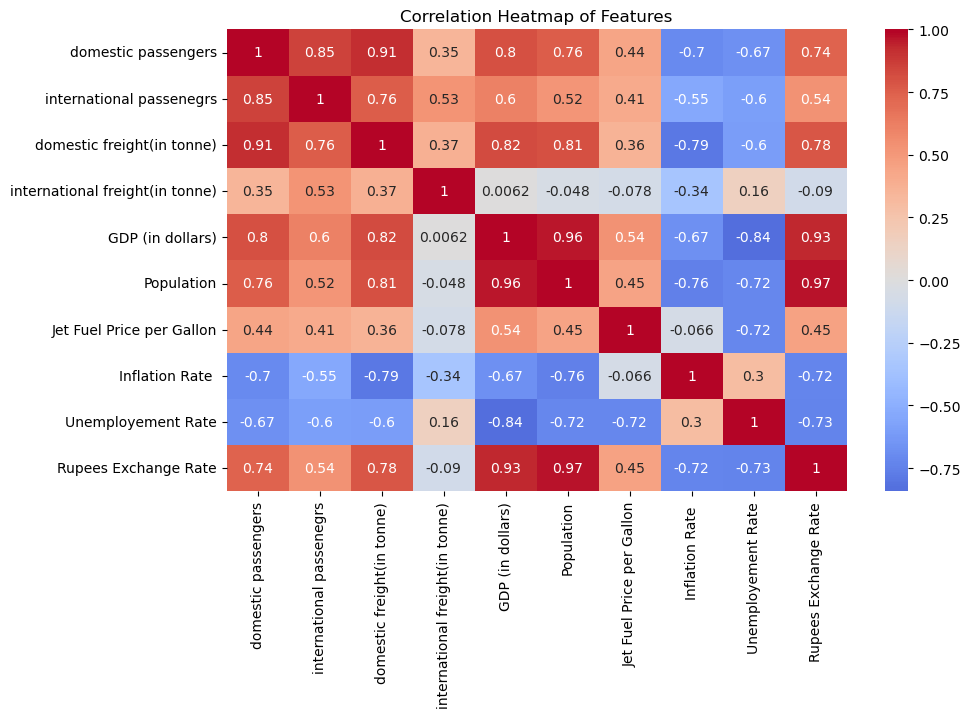

In [6]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Features")
plt.show()


Checking VIF for Multicollinearity Avoidance

In [7]:
df_features = df.drop(columns=['Date'], errors='ignore')

In [8]:
X = add_constant(df_features)

In [9]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

In [10]:
vif_data

,Feature,VIF
0,const,0.000000
1,domestic passengers,11.098441
2,international passenegrs,8.449018
3,domestic freight(in tonne),10.454642
4,international freight(in tonne),6.247591
5,GDP (in dollars),98.539757
6,Population,104.105178
7,Jet Fuel Price per Gallon,2.743612
8,Inflation Rate,6.165365
9,Unemployement Rate,25.621051


Feature Dropping to check VIF 

In [11]:
def calculate_vif(df, thresh=5.0):
    """
    Iteratively drops the feature with the highest VIF 
    until all VIF values are below the threshold.
    
    Parameters:
    -----------
    df : pandas DataFrame (features only, no target column)
    thresh : float, maximum acceptable VIF value
    
    Returns:
    --------
    pd.DataFrame with remaining features and their VIFs
    """
    features = df.copy()
    dropped = []

    while True:
        X = add_constant(features)
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

        # remove the intercept row
        vif_data = vif_data[vif_data["Feature"] != "const"]

        max_vif = vif_data["VIF"].max()
        if max_vif > thresh:
            drop_feature = vif_data.sort_values("VIF", ascending=False)["Feature"].iloc[0]
            print(f"Dropping '{drop_feature}' with VIF = {max_vif:.2f}")
            features = features.drop(columns=[drop_feature])
            dropped.append(drop_feature)
        else:
            break

    print("\n✅ Final Features Selected (VIF < {thresh}):")
    print(vif_data)
    print("\n❌ Dropped Features:")
    print(dropped)
    return vif_data, dropped

In [12]:
vif_result, dropped_features = calculate_vif(df_features, thresh=9.0)

Dropping 'Population' with VIF = 104.11
Dropping 'GDP (in dollars)' with VIF = 25.00
Dropping 'domestic passengers' with VIF = 10.76

✅ Final Features Selected (VIF < {thresh}):
                           Feature       VIF
1         international passenegrs  4.548185
2       domestic freight(in tonne)  6.491254
3  international freight(in tonne)  3.693185
4        Jet Fuel Price per Gallon  2.274133
5                  Inflation Rate   5.308410
6               Unemployement Rate  6.212846
7             Rupees Exchange Rate  7.896657

❌ Dropped Features:
['Population', 'GDP (in dollars)', 'domestic passengers']


Fitting Model On the New Data

In [13]:
df_new = df.copy()
df_new = df_new.drop(columns=['Population','Rupees Exchange Rate'])

In [14]:
df_new.to_csv('Air Traffic Data Cor Updated.csv',index=True)